# 06 — Seizure Forecasting using ARIMAX

**Mục tiêu của phần này:**
1. **Chuyển đổi bài toán:** Chuyển từ "Phát hiện bất thường" (Anomaly Detection bằng phần dư) sang "Dự báo chuỗi thời gian" (Forecasting). 
2. **Mô hình ARIMAX:** Sử dụng mô hình ARIMA kết hợp với các biến ngoại sinh (Exogenous variables - chính là các lag features $t-1, t-2$) để dự đoán năng lượng `RMS` tại thời điểm $t$.
3. **Đánh giá:** Thay vì đo độ chính xác bằng Confusion Matrix, bài toán Hồi quy (Regression) sẽ được đánh giá bằng độ bám sát của đường dự báo với thực tế, thông qua các chỉ số: **MSE, RMSE, MAE**.

Bắt đầu huấn luyện và đánh giá mô hình ARIMAX trên 15 bản ghi...



/mnt/c/Users/DELL/Seizure-Dectection-using-ECoG-/sz_venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/Users/DELL/Seizure-Dectection-using-ECoG-/sz_venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/mnt/c/Users/DELL/Seizure-Dectection-using-ECoG-/sz_venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/mnt/c/Users/DELL/Seizure-Dectection-using-ECoG-/sz_venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

 BÁO CÁO HIỆU NĂNG TRUNG BÌNH (15 FILES)
Mean Squared Error (MSE):       0.00000
Root Mean Squared Error (RMSE): 0.00055
Mean Absolute Error (MAE):      0.00038


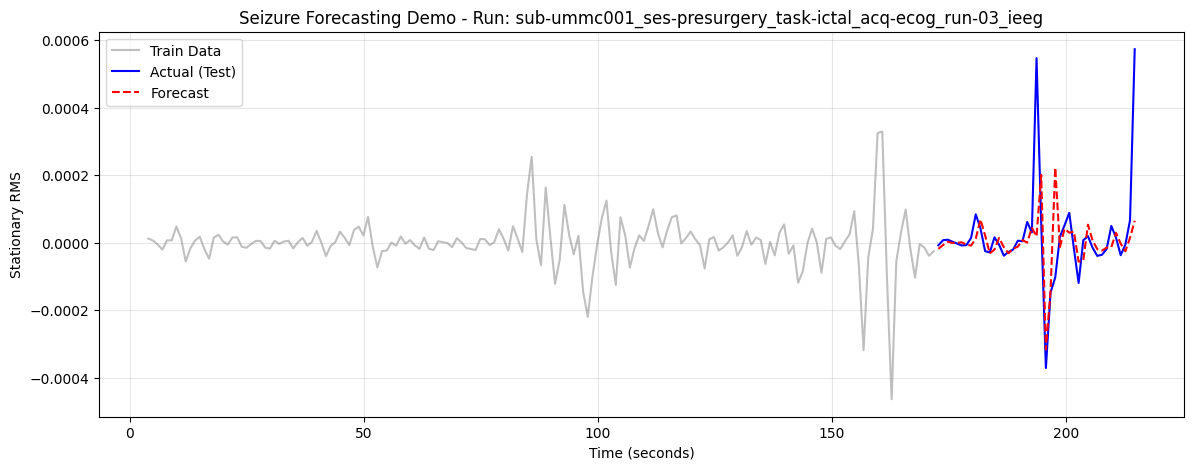

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
import sys

# Cài đặt đường dẫn
ws = Path.cwd().resolve()
src_dir = (ws / 'src' if (ws / 'src').exists() else ws.parent / 'src').resolve()
sys.path.insert(0, str(src_dir))
from ds003029_eda.paths import get_paths
paths = get_paths()

# 1. Load dữ liệu đã stationary
df_stat = pd.read_csv(paths.outputs_dir / "ds003029_stationary_features_multirun.csv")

target_col = 'rms'
exog_cols = [c for c in df_stat.columns if 'lag' in c]

# Lưu trữ các metric của từng file
metrics_list = []
run_ids = df_stat['run_id'].unique()

print(f"Bắt đầu huấn luyện và đánh giá mô hình ARIMAX trên {len(run_ids)} bản ghi...\n")

for i, run in enumerate(run_ids):
    # Lấy dữ liệu của 1 bệnh nhân/run cụ thể
    df_run = df_stat[df_stat['run_id'] == run].copy()
    
    # Bỏ qua các run quá ngắn không đủ dữ liệu train
    if len(df_run) < 50:
        continue
        
    # Chia Train/Test (80% đầu, 20% cuối) theo đúng thứ tự thời gian
    train_size = int(len(df_run) * 0.8)
    train, test = df_run.iloc[:train_size], df_run.iloc[train_size:]
    
    y_train, X_train = train[target_col], train[exog_cols]
    y_test, X_test = test[target_col], test[exog_cols]
    
    try:
        # Khởi tạo & Train mô hình (d=0 vì đã lấy sai phân ở bài trước)
        model = ARIMA(endog=y_train, exog=X_train, order=(1, 0, 1))
        fitted_model = model.fit()
        
        # Dự báo
        preds = fitted_model.predict(start=len(train), end=len(train)+len(test)-1, exog=X_test)
        
        # Tính toán lỗi
        mse = mean_squared_error(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mse)
        
        metrics_list.append({'run_id': run, 'mse': mse, 'rmse': rmse, 'mae': mae})
        
        # Lưu lại preds của file cuối cùng để vẽ biểu đồ minh họa
        if i == len(run_ids) - 1:
            test_for_plot = test.copy()
            test_for_plot['predictions'] = preds.values
            train_for_plot = train.copy()
            
    except Exception as e:
        print(f"Lỗi khi huấn luyện run {run}: {e}")

# 2. Tổng hợp báo cáo Hiệu năng chung
df_metrics = pd.DataFrame(metrics_list)
print("="*45)
print(" BÁO CÁO HIỆU NĂNG TRUNG BÌNH (15 FILES)")
print("="*45)
print(f"Mean Squared Error (MSE):       {df_metrics['mse'].mean():.5f}")
print(f"Root Mean Squared Error (RMSE): {df_metrics['rmse'].mean():.5f}")
print(f"Mean Absolute Error (MAE):      {df_metrics['mae'].mean():.5f}")
print("="*45)

# 3. Trực quan hóa Actual vs Forecast cho bản ghi cuối cùng
if 'test_for_plot' in locals():
    plt.figure(figsize=(14, 5))
    plt.plot(train_for_plot['t_mid_s'], train_for_plot['rms'], label='Train Data', color='gray', alpha=0.5)
    plt.plot(test_for_plot['t_mid_s'], test_for_plot['rms'], label='Actual (Test)', color='blue', linewidth=1.5)
    plt.plot(test_for_plot['t_mid_s'], test_for_plot['predictions'], label='Forecast', color='red', linestyle='--', linewidth=1.5)
    plt.title(f"Seizure Forecasting Demo - Run: {df_metrics.iloc[-1]['run_id']}")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Stationary RMS')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 3. Trực quan hóa Chuyên sâu (Advanced Visualization)
Để hiểu rõ hành vi của mô hình ARIMAX, ta sẽ vẽ 3 biểu đồ cho bản ghi cuối cùng:
1. **Biểu đồ Chuỗi thời gian (Time Series):** So sánh trực tiếp đường RMS thực tế (Xanh) và đường RMS dự báo (Đỏ).
2. **Biểu đồ Sai số Tuyệt đối (Absolute Error):** Theo dõi mức độ sai lệch của mô hình theo thời gian. Nếu sai số vọt lên quá cao tại một thời điểm, nghĩa là có một sự biến động sóng não bất ngờ mà các biến trễ (lags) không lường trước được.
3. **Biểu đồ Tương quan (Scatter Plot):** Đánh giá mức độ bám sát thực tế. Lý tưởng nhất là các điểm dữ liệu nằm dọc theo đường chéo màu đỏ (Actual = Forecast).

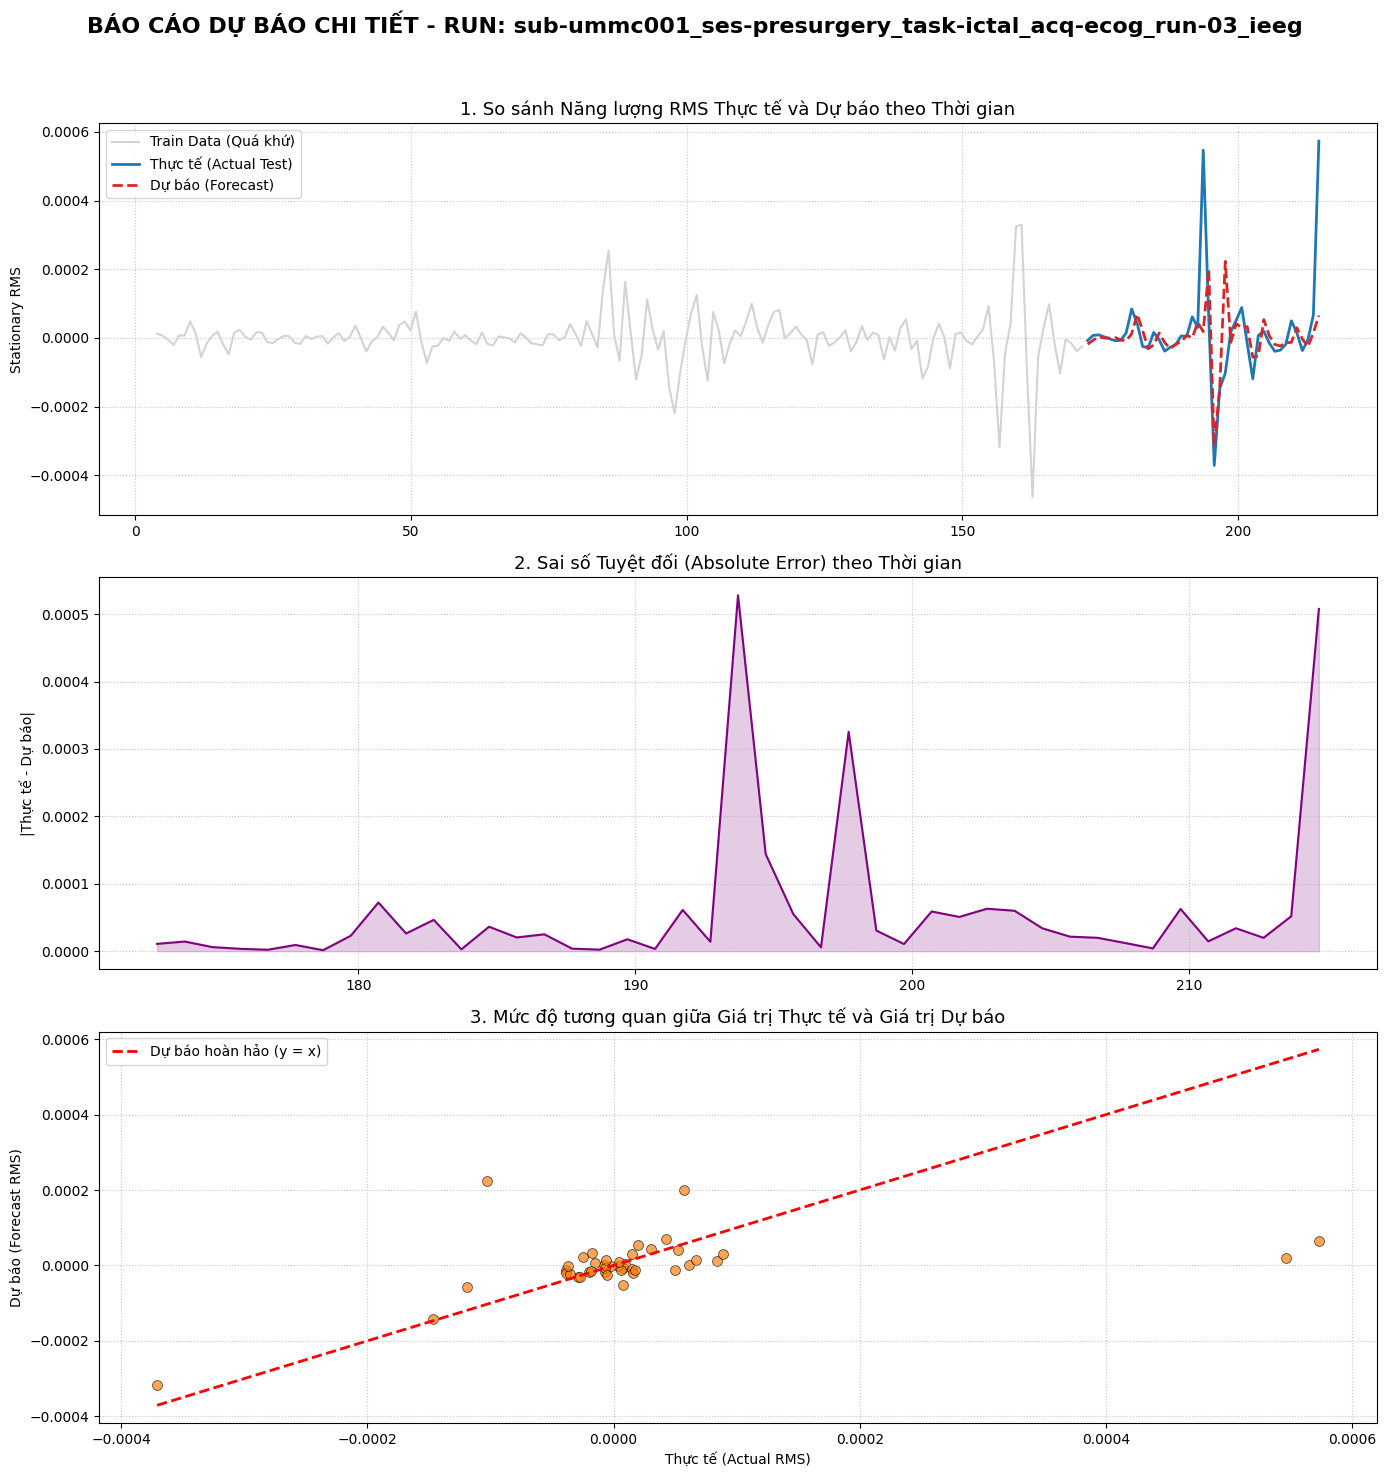

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra xem có dữ liệu plot từ vòng lặp trước không
if 'test_for_plot' in locals() and 'train_for_plot' in locals():
    # Tính toán sai số tuyệt đối
    test_for_plot['abs_error'] = abs(test_for_plot['rms'] - test_for_plot['predictions'])
    
    # Khởi tạo bảng vẽ gồm 3 biểu đồ xếp dọc
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    run_name = df_metrics.iloc[-1]['run_id']
    fig.suptitle(f"BÁO CÁO DỰ BÁO CHI TIẾT - RUN: {run_name}", fontsize=16, fontweight='bold', y=0.92)

    # =========================================================
    # 1. BIỂU ĐỒ CHUỖI THỜI GIAN (ACTUAL vs FORECAST)
    # =========================================================
    axes[0].plot(train_for_plot['t_mid_s'], train_for_plot['rms'], label='Train Data (Quá khứ)', color='lightgray')
    axes[0].plot(test_for_plot['t_mid_s'], test_for_plot['rms'], label='Thực tế (Actual Test)', color='#1f77b4', linewidth=2)
    axes[0].plot(test_for_plot['t_mid_s'], test_for_plot['predictions'], label='Dự báo (Forecast)', color='#d62728', linestyle='--', linewidth=2)
    
    axes[0].set_title('1. So sánh Năng lượng RMS Thực tế và Dự báo theo Thời gian', fontsize=13)
    axes[0].set_ylabel('Stationary RMS')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # =========================================================
    # 2. BIỂU ĐỒ SAI SỐ (ABSOLUTE ERROR TẠI TẬP TEST)
    # =========================================================
    axes[1].plot(test_for_plot['t_mid_s'], test_for_plot['abs_error'], color='purple', linewidth=1.5)
    axes[1].fill_between(test_for_plot['t_mid_s'], test_for_plot['abs_error'], color='purple', alpha=0.2)
    
    axes[1].set_title('2. Sai số Tuyệt đối (Absolute Error) theo Thời gian', fontsize=13)
    axes[1].set_ylabel('|Thực tế - Dự báo|')
    axes[1].grid(True, linestyle=':', alpha=0.7)

    # =========================================================
    # 3. BIỂU ĐỒ TƯƠNG QUAN (SCATTER PLOT)
    # =========================================================
    sns.scatterplot(
        x='rms', y='predictions', 
        data=test_for_plot, 
        ax=axes[2], 
        color='#ff7f0e', 
        edgecolor='k',
        alpha=0.7,
        s=50
    )
    
    # Vẽ đường chéo y = x (Đường dự báo hoàn hảo)
    min_val = min(test_for_plot['rms'].min(), test_for_plot['predictions'].min())
    max_val = max(test_for_plot['rms'].max(), test_for_plot['predictions'].max())
    axes[2].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Dự báo hoàn hảo (y = x)')
    
    axes[2].set_title('3. Mức độ tương quan giữa Giá trị Thực tế và Giá trị Dự báo', fontsize=13)
    axes[2].set_xlabel('Thực tế (Actual RMS)')
    axes[2].set_ylabel('Dự báo (Forecast RMS)')
    axes[2].legend()
    axes[2].grid(True, linestyle=':', alpha=0.7)

    # Hiển thị
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()
else:
    print("Không tìm thấy dữ liệu để vẽ biểu đồ. Hãy đảm bảo bạn đã chạy cell huấn luyện ARIMAX ở trên.")

Biểu đồ 1 (Trên cùng): Hãy nhìn vào những đoạn mà đường màu Xanh (Thực tế) vọt lên cao - đó là những lúc năng lượng não bùng phát. Nếu đường màu Đỏ (Dự báo) cũng vọt lên theo sát nút, mô hình của bạn cực kỳ thành công. Nếu đường đỏ luôn trễ 1 nhịp so với đường xanh, tức là mô hình đang bị phụ thuộc quá nhiều vào lag1 (Nó chỉ biết nói "Giây này cao vì giây trước cao").

Biểu đồ 2 (Ở giữa): Những đỉnh nhọn màu tím cho bạn biết mô hình "đoán trượt" nặng nhất ở giây thứ bao nhiêu. Những điểm trượt này thường rơi đúng vào khoảnh khắc bắt đầu (onset) của cơn động kinh.

Biểu đồ 3 (Dưới cùng): Càng nhiều chấm cam bám sát vào đường đứt nét màu đỏ, mô hình của bạn dự báo càng chính xác. Nếu các chấm cam nằm la liệt theo chiều ngang, nghĩa là tín hiệu thực tế có thay đổi thì mô hình vẫn chỉ đoán ra 1 giá trị bình bình.